In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import geopandas as gpd
import pandas as pd
import os

from shapely.geometry import box
import numpy as np
import folium

import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask

In [2]:
def extract_population(shape, raster):
    geom = [shape]
    out_image, out_transform = mask(raster, geom, crop=True)
    nodata_value = raster.nodata
    out_image = np.where(out_image == nodata_value, 0, out_image)    
    return out_image.sum()

In [3]:
ghana = gpd.read_file("./gh_shp/gh.shp")
raster_path = "./ghana_population.tif"
raster = rasterio.open(raster_path)

# select region
ghana = ghana[ghana["name"]=="Eastern"]

In [7]:
# Define the bounding box of Ghana
minx, miny, maxx, maxy = ghana.total_bounds

# Grid cell size (in degrees or meters depending on the CRS)
cell_size = 0.02
grid_cells = []
for x in np.arange(minx, maxx, cell_size):
    for y in np.arange(miny, maxy, cell_size):
        grid_cells.append(box(x, y, x+cell_size, y+cell_size))

grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=ghana.crs)
grid_within_ghana = gpd.overlay(grid, ghana, how='intersection')

In [8]:
ghana.loc[:, 'Population'] = ghana['geometry'].apply(lambda x: extract_population(x, raster))
grid_within_ghana.loc[:, 'Population'] = grid_within_ghana['geometry'].apply(lambda x: extract_population(x, raster))

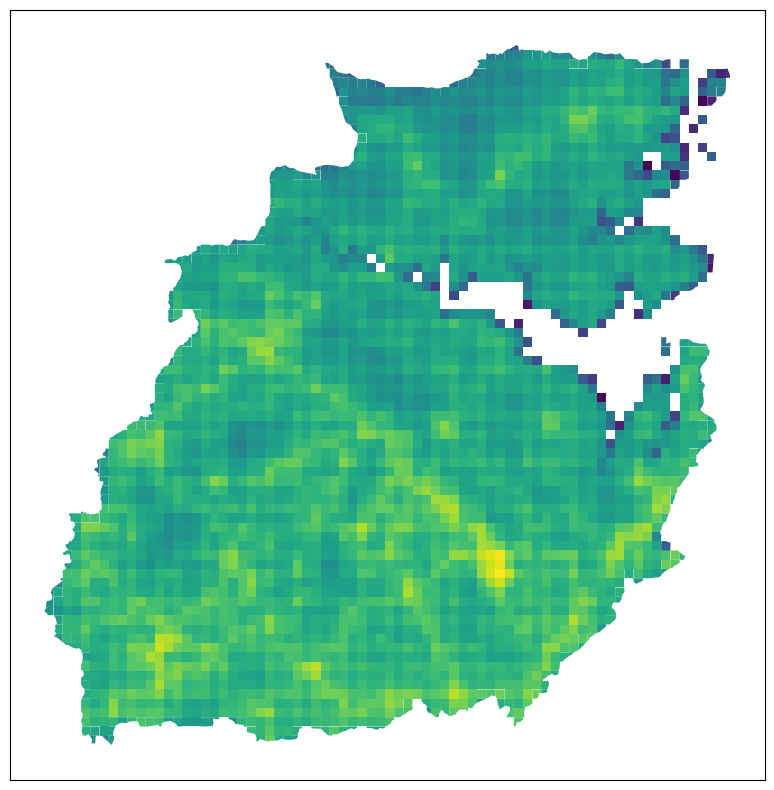

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))
grid_within_ghana.plot(
    column='Population',
    cmap='viridis',
    legend=False,  # Disable the default legend
    ax=ax,
    norm=LogNorm()
)
ax.set_xticks([])
ax.set_yticks([])

# # Create colorbar that matches the height of the plot
# sm = mpl.cm.ScalarMappable(cmap='viridis', norm=LogNorm(vmin=grid_within_ghana['Population'].min() + 1, 
#                                                         vmax=grid_within_ghana['Population'].max()))
# sm._A = []  # Required for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)  # Adjust `fraction` and `pad` for size and spacing
# cbar.set_label('Population')

plt.savefig("ghana_pop_density.pdf", bbox_inches="tight")
plt.show()

In [32]:
# Extract grid boundaries and population into a numpy array
grid_array = np.zeros((len(grid_within_ghana), 3))  # x, y, property
for i, row in grid_within_ghana.iterrows():
    centroid = row['geometry'].centroid
    grid_array[i] = [centroid.x, centroid.y, row['Population']]

In [33]:
num_bins = 75

# Define grid resolution
lon_bins = np.linspace(grid_array[:, 0].min(), grid_array[:, 0].max(), num_bins)  # Adjust bins
lat_bins = np.linspace(grid_array[:, 1].min(), grid_array[:, 1].max(), num_bins)  # Adjust bins

# Create a meshgrid for longitude and latitude
lon_grid, lat_grid = np.meshgrid(lon_bins, lat_bins)

# Initialize the 3D grid for population with zeros
population_grid = np.zeros((len(lat_bins), len(lon_bins), 1))

# Map population to the grid
for lon, lat, pop in grid_array:
    lon_idx = np.abs(lon_bins - lon).argmin()  # Closest longitude index
    lat_idx = np.abs(lat_bins - lat).argmin()  # Closest latitude index
    population_grid[lat_idx, lon_idx, 0] += pop  # Assign population

np.save("ghana_grid", population_grid)

In [30]:
# #Define coordinates of where we want to center our map
# coords = [6.1018, 0.1277]

# #Create the map
# my_map = folium.Map(location = coords, zoom_start = 15)

# #Display the map
# my_map